<a href="https://colab.research.google.com/github/mas622424/Quantum-computing-codes/blob/main/PennyLane_101_April_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.1 MB/s eta 0:00:00


# PennyLane 101


1.   Quantum functions and QNodes
2.   Devices
3.   Templates
4.   Debugging tips


In [ ]:
# import your new favourite library
import pennylane as qp
qp.about()
# Go to pennylane.ai to see if you're using the most recent stable version

Name: pennylane
Version: 0.44.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Platform info:           Linux-6.6.113+-x86_64-with-glibc2.35
Python version:          3.12.13
Numpy version:           2.0.2
Scipy version:           1.16.3
JAX version:             0.7.2
Installed devices:
- default.clifford (pennylane-0.44.1)
- default.gaussian (pennylane-0.44.1)
- default.mixed (pennylane-0.44.1)
- default.qubit (pennylane-0.44.1)
- default.qutrit (pennylane-0.44.1)
- default.qutrit.mixed (pennylane-0.44.1)
- default.tensor (pennylane-0.44.1)
- null.qubit (pennylane-0.44.1)
- reference.qubit (pennylane-0.44.1)
- lightning.qubit (pennylane_lightning-0.44.0)


## Quantum functions and QNodes
A quantum function is just a Python function that includes quantum gates and a [measurement](https://pennylane.ai/codebook/pennylane-fundamentals/measurements-in-pennylane).

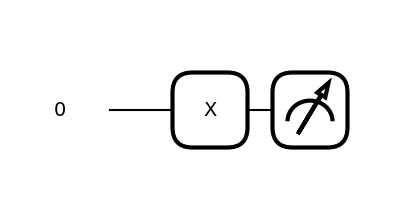

In [ ]:
# This is a quantum function
def circuit():
  qp.X(wires=0)
  return qp.probs()

qp.draw_mpl(circuit)();

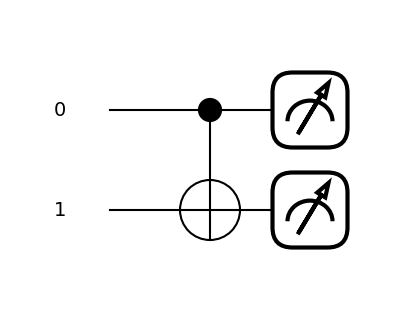

In [ ]:
# This is also a quantum function
def circuit():
  qp.CNOT(wires=[0,1])
  return qp.probs()

qp.draw_mpl(circuit)();

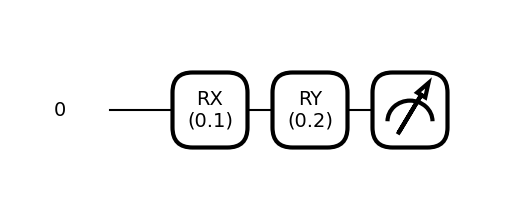

In [ ]:
# This is a quantum function where the gates take parameters
def circuit():
  qp.RX(0.1,wires=0)
  qp.RY(0.2,wires=0)
  return qp.probs()

qp.draw_mpl(circuit, decimals=1)();

QNodes allow you to run your quantum function on a specific device (simulator or actual quantum hardware).


**💡 Tip:** Not everything needs to be a qnode, sometimes quantum functions are enough.

In [ ]:
# device
dev = qp.device('default.qubit')
# This is a qnode
qnode_1 = qp.QNode(circuit,dev)

# This is also a qnode (this is the preferred way to create a qnode)
@qp.qnode(dev)
def circuit(x,y):
  qp.RX(x,wires=0)
  qp.RY(y,wires=0)
  return qp.probs()

# Run your circuit by simply calling the function
circuit(0.1, 0.2)

array([0.98758516, 0.01241484])

The output tells us that there's over 90% chance to measure our qubit in the |0$\rangle$ state and only a small chance of measuring our qubit in the |1$\rangle$ state.

## Devices
**💡 Tip:** lightning.qubit and default.qubit are usually a safe bet.

In [ ]:
# Go to pennylane.ai/performance#which-simulator to learn about different devices
# Prioritize default.qubit for small simulations or lightning.qubit for larger ones

dev = qp.device('default.qubit')

# When using default.qubit you don't need to specify the wires (number of qubits)
# When using other devices you do need to specify the wires
dev_l = qp.device('lightning.qubit', wires=3)

## Templates
Find them in the docs 👉
https://docs.pennylane.ai/en/stable/introduction/templates.html

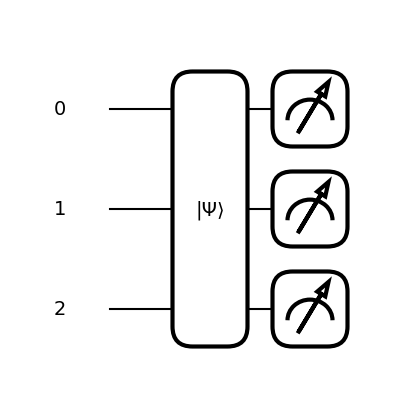

In [ ]:
# Create a qnode
@qp.qnode(dev_l)
def circuit():

  # add the template within the function and apply it on a specific set of wires
  qp.BasisEmbedding([1,1,0],wires=[0,1,2])

  # return a measurement
  return qp.probs()

# Draw your circuit
qp.draw_mpl(circuit)();

array([0., 0., 0., 0., 0., 0., 1., 0.])

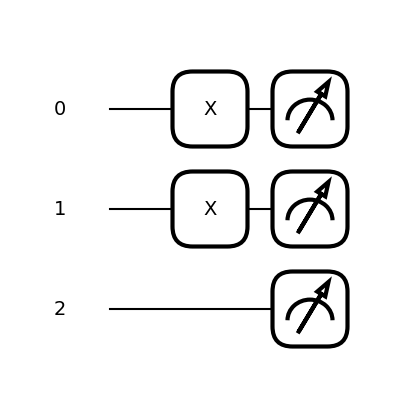

In [ ]:
# You can decompose the template into gates
circuit2 = qp.transforms.decompose(circuit)

# Draw your circuit
qp.draw_mpl(circuit2, show_all_wires=True)();

# Run your circuit
circuit2()

## Debugging tips

💡 Our Discussion Forum is a gold mine for answers to common questions ([discuss.pennylane.ai](https://discuss.pennylane.ai)).

💡 Use the PennyLane docs as your source of truth ([docs.pennylane.ai](https://docs.pennylane.ai)).

💡 Check the source code directly from the PennyLane docs.

💡 Use the [PennyLane Codebook](https://pennylane.ai/codebook) both for theory and practice.

💡 If something used to work and it doesn't anymore, look at the Release News section of the docs ([release notes](https://docs.pennylane.ai/en/stable/development/release_notes.html), [deprecations](https://docs.pennylane.ai/en/stable/development/deprecations.html), and other updates).

💡 Use our tools for [inspecting circuits](https://docs.pennylane.ai/en/stable/introduction/inspecting_circuits.html) including qp.specs(), circuit drawing, mid-circuit snapshots, interactive debugging, Fourier representation, and more.



# ____________

Copyright 2026 Xanadu Quantum Technologies Inc.

Please do not distribute this material outside of your organization.

Unless required by applicable law or agreed to in writing, software distributed
under this training is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR
CONDITIONS OF ANY KIND, either express or implied.